In [9]:
import tensorflow as tf
tf.__version__

'2.9.0'

In [10]:
import os
# Walk through the file and list the number of files
for dirpath, dirnames, filenames in os.walk("images"):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'")

There are 2 directories and 0 images in 'images'
There are 7 directories and 0 images in 'images/test'
There are 0 directories and 1774 images in 'images/test/happy'
There are 0 directories and 1247 images in 'images/test/sad'
There are 0 directories and 1024 images in 'images/test/fear'
There are 0 directories and 831 images in 'images/test/surprise'
There are 0 directories and 1233 images in 'images/test/neutral'
There are 0 directories and 958 images in 'images/test/angry'
There are 0 directories and 111 images in 'images/test/disgust'
There are 7 directories and 0 images in 'images/train'
There are 0 directories and 7215 images in 'images/train/happy'
There are 0 directories and 4830 images in 'images/train/sad'
There are 0 directories and 4097 images in 'images/train/fear'
There are 0 directories and 3171 images in 'images/train/surprise'
There are 0 directories and 4965 images in 'images/train/neutral'
There are 0 directories and 3995 images in 'images/train/angry'
There are 0 di

['PrivateTest_59389857.jpg']


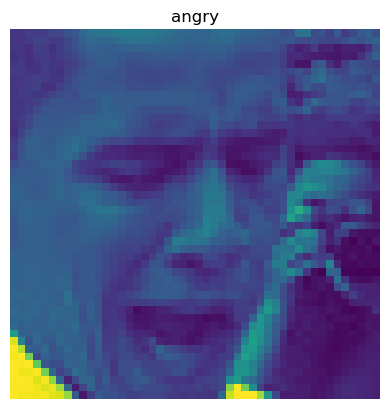

Image shape (48, 48)
['PrivateTest_70570336.jpg']


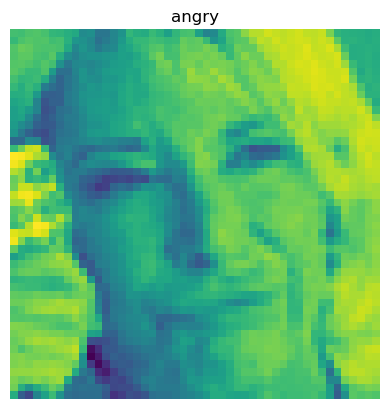

Image shape (48, 48)
['PrivateTest_7969511.jpg']


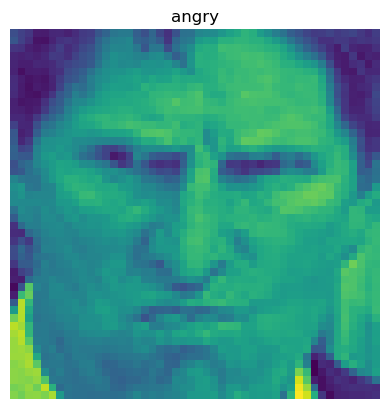

Image shape (48, 48)
['PrivateTest_51610150.jpg']


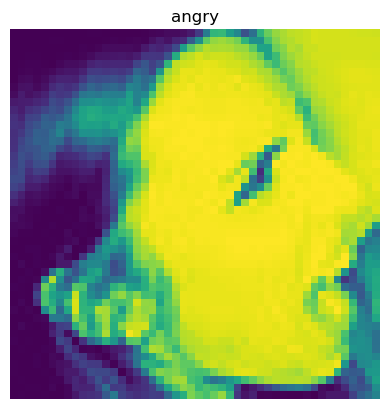

Image shape (48, 48)
['PrivateTest_56782878.jpg']


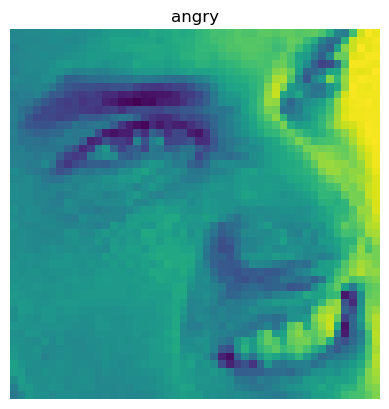

Image shape (48, 48)
['PublicTest_3218764.jpg']


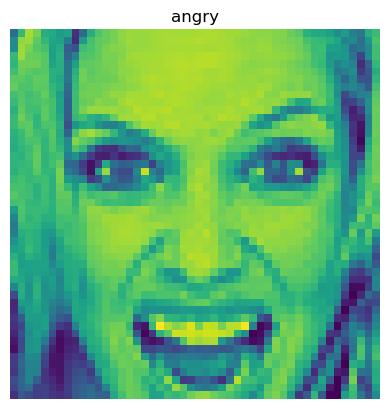

Image shape (48, 48)
['PrivateTest_58143145.jpg']


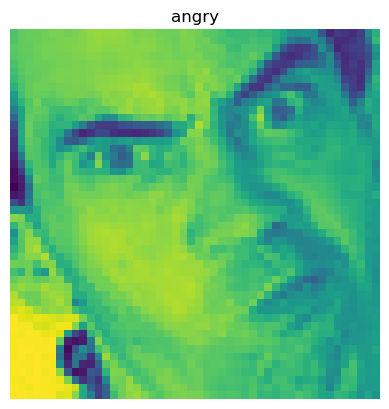

Image shape (48, 48)
['PublicTest_89354196.jpg']


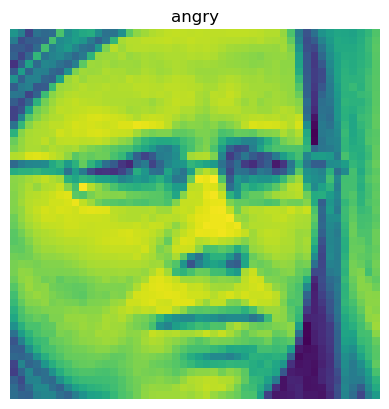

Image shape (48, 48)
['PublicTest_48232878.jpg']


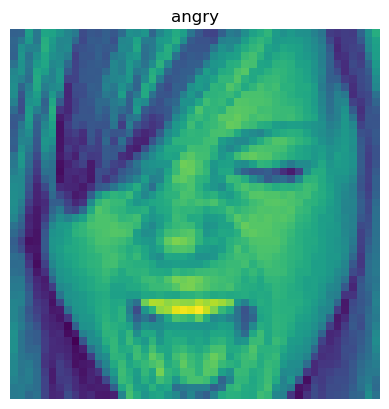

Image shape (48, 48)
['PublicTest_69709353.jpg']


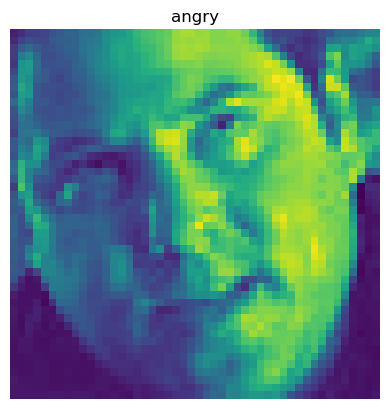

Image shape (48, 48)


In [11]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

def view_random_image(target_dir,target_class):
  # Setup target directory
  target_folder = target_dir+target_class

  #Get random image path
  random_image = random.sample(os.listdir(target_folder),1)
  print(random_image)

  #Read in the image and plot it using matplotlib
  img = mpimg.imread(target_folder+"/"+random_image[0])
  plt.imshow(img)
  plt.title(target_class)
  plt.axis("off")
  plt.show()

  print(f"Image shape {img.shape}") # Shows the shape of the image

  return img


for i in range(10):
  img = view_random_image(target_dir="images/test/",
                        target_class="angry")

In [12]:
img = tf.cast(tf.constant(img),dtype=tf.float32)
img

<tf.Tensor: shape=(48, 48), dtype=float32, numpy=
array([[12., 18., 26., ..., 57., 64., 65.],
       [17., 28., 34., ..., 71., 86., 77.],
       [24., 42., 48., ..., 77., 79., 70.],
       ...,
       [10.,  8.,  8., ...,  8.,  5.,  6.],
       [ 9.,  9.,  8., ...,  8.,  5.,  7.],
       [ 9.,  9.,  9., ...,  7.,  6.,  9.]], dtype=float32)>

In [13]:
img.shape

TensorShape([48, 48])

In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

tf.random.set_seed(42)

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_dir="images/train/"
test_dir="images/test/"

train_data = train_datagen.flow_from_directory(train_dir,
                                               batch_size=16,
                                               target_size=(128,128),
                                               class_mode="categorical",
                                               seed=42)
test_data = test_datagen.flow_from_directory(test_dir,
                                             batch_size=16,
                                             target_size=(128,128),
                                             class_mode="categorical",
                                             seed=42)


# 1. Create a base model with tf.keras.applciations
base_model = tf.keras.applications.vgg19.VGG19(include_top=False) # include_top -> last layer (will be different for different datasets)

# 2. Freeze the base model, underlying pre-trained weights arent updated during training
base_model.trainable=False

# 3. Create inputs into our model
inputs = tf.keras.layers.Input(shape=(128,128,3),
                               name="input_layer")

# 4. (Optional) -> if using resnet -> need to normalize inputs -> not needed for EfficientNet
# x = tf.keras.layers.experimental.preprocessing.Rescaling(1./255)(inputs)

# 5. Pass the inputs to base_model
x = base_model(inputs)

print("shape after passing inputs through base_model: "+str(x.shape))

# 6. Average pool the outputs of the base_model (aggregate all most of information, reduce number of computations)
x = tf.keras.layers.GlobalAveragePooling2D(name="average_global_pooling_layer")(x)

print("Shape after GlobalAveragePooling2D: "+str(x.shape))

# 7. Create the output activation layer
outputs = tf.keras.layers.Dense(7,activation=tf.keras.activations.softmax,name="output_layers")(x)

# 8. Combine input with the outputs into a model
model_0 = tf.keras.Model(inputs,outputs)

# 9. Compile the model
model_0.compile(loss=tf.keras.losses.CategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['accuracy'])

# 10. Fit the model
history_0 = model_0.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=test_data,
                        validation_steps=len(test_data))

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
shape after passing inputs through base_model: (None, 4, 4, 512)
Shape after GlobalAveragePooling2D: (None, 512)
Epoch 1/5


2023-05-31 17:31:47.273386: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


1795/1795 [==============================] - ETA: 0s - loss: 1.6748 - accuracy: 0.3383

2023-05-31 17:37:43.835456: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


1795/1795 [==============================] - 448s 249ms/step - loss: 1.6748 - accuracy: 0.3383 - val_loss: 1.5980 - val_accuracy: 0.3810
Epoch 2/5
1795/1795 [==============================] - 462s 258ms/step - loss: 1.5737 - accuracy: 0.3890 - val_loss: 1.5663 - val_accuracy: 0.3849
Epoch 3/5
 444/1795 [======>.......................] - ETA: 4:29 - loss: 1.5415 - accuracy: 0.3978

KeyboardInterrupt: 

In [15]:
model_0.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 128, 128, 3)]     0         
                                                                 
 vgg19 (Functional)          (None, None, None, 512)   20024384  
                                                                 
 average_global_pooling_laye  (None, 512)              0         
 r (GlobalAveragePooling2D)                                      
                                                                 
 output_layers (Dense)       (None, 7)                 3591      
                                                                 
Total params: 20,027,975
Trainable params: 3,591
Non-trainable params: 20,024,384
_________________________________________________________________


In [ ]:
model_0.evaluate(test_data)

225/225 [==============================] - 18s 78ms/step - loss: 1.5638 - accuracy: 0.3876


[1.5637799501419067, 0.38757315278053284]

In [ ]:
#hello